# Language Support OCR: Handwriting & Signature

Extracts handwriting with Mistral OCR-4 and renders the English result as Markdown.

In [ ]:
import re
from pathlib import Path
import requests

from dotenv import load_dotenv
from IPython.display import Image, display

from ocr4_utils import OCRConfig, call_ocr4, encode_file, extract_text

# Azure Foundry document annotation for check fields
import json
import mimetypes

from ocr4_utils import call_ocr4, extract_text, page_confidence, plot_bounding_boxes


load_dotenv()
config = OCRConfig.from_env()
ENDPOINT = config.endpoint
MODEL_NAME = config.model_name
HEADERS = config.headers
encode_image = encode_file


In [3]:
# Extract structured check fields from the OCR-4 response

def extract_check_data(ocr_response: dict) -> dict:
    ocr_text = extract_text(ocr_response)
    text = " ".join(ocr_text.split())
    labels = [
        'name of the bank',
        'financial institution',
        'pay to the order',
        'authorized signature',
        'amount of the check',
        'date of the check',
        'check number',
        'cheque number',
        'check amount',
        'cheque amount',
        'check notes',
        'cheque notes',
        'check date',
        'check no',
        'cheque no',
        'check #',
        'signature',
        'signed by',
        'bank name',
        'notes',
        'memo',
        'amount',
        'date',
        'bank',
    ]
    stop_labels = [label for label in labels if label != 'bank']
    label_pattern = "|".join(
        re.escape(label) for label in sorted(stop_labels, key=len, reverse=True)
    )

    def value_after_label(field_labels: list[str]) -> str | None:
        field_pattern = "|".join(
            re.escape(label) for label in sorted(field_labels, key=len, reverse=True)
        )
        match = re.search(
            rf"(?:{field_pattern})\s*[:#-]?\s*(.+?)(?=\s+(?:{label_pattern})\s*[:#-]?\s*|$)",
            text,
            flags=re.IGNORECASE,
        )
        return match.group(1).strip() if match else None

    check_number = value_after_label(
        ['check number', 'check no', 'check #', 'cheque number', 'cheque no']
    )
    if check_number is None:
        six_digit_numbers = re.findall(r'(?<!\d)\d{6}(?!\d)', text)
        check_number = six_digit_numbers[-1] if six_digit_numbers else None

    bank_name = value_after_label(
        ['bank name', 'name of the bank', 'bank', 'financial institution']
    )
    pay_to_the_order = value_after_label(['pay to the order of', 'pay to the order'])
    if pay_to_the_order:
        payee_end = re.search(
            r'\s+(?=(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|'
            r'Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|'
            r'Nov(?:ember)?|Dec(?:ember)?)\s+\d{1,2}\s+\d{2,4}\b|\$)',
            pay_to_the_order,
            flags=re.IGNORECASE,
        )
        if payee_end:
            pay_to_the_order = pay_to_the_order[:payee_end.start()].strip(' ,:-')

    signature = value_after_label(['signature', 'authorized signature', 'signed by'])
    if signature is None:
        name_matches = re.findall(
            r"(?=(\b[A-Z][a-z]+(?:['-][A-Z][a-z]+)?\s+[A-Z][a-z]+(?:['-][A-Z][a-z]+)?\b))",
            text,
        )
        signature = name_matches[-1] if name_matches else None

    check_notes = value_after_label(['check notes', 'cheque notes', 'notes', 'memo'])
    bank_start = re.search(r'\b(?:[A-Z][A-Za-z]*\s+)?[A-Z][A-Za-z]*Bank\b', text)
    if bank_start:
        bank_text = text[bank_start.start():]
        address_end = re.search(r'\b[A-Z]{2}\b', bank_text)
        if address_end:
            bank_end = bank_start.start() + address_end.end()
            bank_name = text[bank_start.start():bank_end].strip(' ,')
            remaining_text = text[bank_end:].strip()
            if remaining_text:
                check_notes = (
                    f'{check_notes} {remaining_text}'.strip()
                    if check_notes
                    else remaining_text
                )

    check_amount = value_after_label(
        ['check amount', 'cheque amount', 'amount of the check', 'amount']
    )
    check_date = value_after_label(['date of the check', 'check date', 'date'])
    date_match = re.search(
        r'\b(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|'
        r'Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|'
        r'Nov(?:ember)?|Dec(?:ember)?)\s+\d{1,2}\s+\d{2,4}\b',
        text,
        flags=re.IGNORECASE,
    )
    if date_match:
        check_date = date_match.group(0)

    if check_amount is None:
        amount_match = re.search(r"(?:\$\s*)?\d{1,3}(?:,\d{3})*(?:\.\d{2})", text)
        check_amount = amount_match.group(0) if amount_match else None

    return {
        'check_number': check_number,
        'bank_name': bank_name,
        'pay_to_the_order': pay_to_the_order,
        'signature': signature,
        'check_notes': check_notes,
        'check_amount': check_amount,
        'check_date': check_date,
        'amount_of_the_check': check_amount,
    }


In [4]:
# Extract tables, figure interpretation, and conclusion from the handwritten sample

def extract_handwritten_sample_analysis(ocr_response: dict) -> dict:
    normalized_text = extract_text(ocr_response)
    markdown_parts = [
        page.get('markdown', '')
        for page in ocr_response.get('pages', [])
        if page.get('markdown')
    ]
    markdown_text = '\n'.join(markdown_parts) or normalized_text

    def parse_table_row(row: str) -> list[str]:
        return [cell.strip() for cell in row.strip().strip('|').split('|')]

    tables = []
    lines = markdown_text.splitlines()
    line_index = 0
    while line_index < len(lines) - 1:
        header_line = lines[line_index].strip()
        separator_line = lines[line_index + 1].strip()
        if (
            header_line.startswith('|')
            and header_line.endswith('|')
            and re.fullmatch(r'\|?\s*:?-+:?\s*(?:\|\s*:?-+:?\s*)+\|?', separator_line)
        ):
            headers = parse_table_row(header_line)
            rows = []
            line_index += 2
            while line_index < len(lines) and lines[line_index].strip().startswith('|'):
                values = parse_table_row(lines[line_index])
                rows.append(dict(zip(headers, values)))
                line_index += 1
            tables.append({'headers': headers, 'rows': rows})
            continue
        line_index += 1

    figures = []
    figure_pattern = re.compile(r'!\[([^]]*)\]\(([^)]+)\)')
    for figure_match in figure_pattern.finditer(markdown_text):
        following_text = markdown_text[figure_match.end():].strip()
        interpretation = re.split(r'\n\s*#{1,6}\s+', following_text, maxsplit=1)[0].strip()
        figures.append(
            {
                'alt_text': figure_match.group(1),
                'source': figure_match.group(2),
                'interpretation': interpretation,
            }
        )

    conclusion_match = re.search(
        r'(?ims)^\s*#{1,6}\s*(?:\d+[.)]\s*)?conclusion\s*\n(.*?)(?=^\s*#{1,6}\s+|\Z)',
        markdown_text,
    )
    conclusion = conclusion_match.group(1).strip() if conclusion_match else None

    return {
        'text': normalized_text,
        'tables': tables,
        'figures': figures,
        'figure_interpretation': ' '.join(
            figure['interpretation'] for figure in figures if figure['interpretation']
        ) or None,
        'conclusion': conclusion,
    }


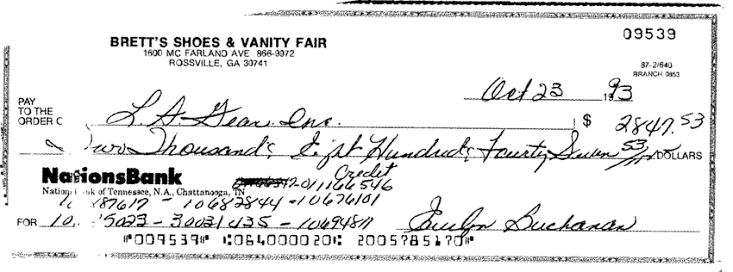

In [5]:
IMAGE_PATH = Path.cwd() / 'samples' / 'check.png'

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Could not find {IMAGE_PATH}')
display(Image(filename=str(IMAGE_PATH)))

In [6]:
ocr_response = call_ocr4(IMAGE_PATH)
text = extract_text(ocr_response)
display('OCR text:', text)

'OCR text:'

"# BRETT'S SHOES & VANITY FAIR 1600 MC FARLAND AVE 866-9372 ROSSVILLE, GA 30741 09539 87-2/640 BRANCH 3853 PAY TO THE ORDER C L.A. Dean, Inc. Oct 23 93 $ 2847.53 Two Thousand Eight Hundred Forty Seven 53/100 DOLLARS NationsBank Nations Bank of Tennessee, N.A., Chattanooga, TN 10487617 - 10487844 - 10476101 FOR 10. 5023 - 30031435 - 1049481 Evelyn Buchanan 009539 064000020 2005785170"

In [7]:

text = extract_check_data(ocr_response)
display('OCR text:', text)


'OCR text:'

{'check_number': '009539',
 'bank_name': 'DOLLARS NationsBank Nations Bank of Tennessee, N.A., Chattanooga, TN',
 'pay_to_the_order': 'C L.A. Dean, Inc.',
 'signature': 'Evelyn Buchanan',
 'check_notes': '10487617 - 10487844 - 10476101 FOR 10. 5023 - 30031435 - 1049481 Evelyn Buchanan 009539 064000020 2005785170',
 'check_amount': '847.53',
 'check_date': 'Oct 23 93',
 'amount_of_the_check': '847.53'}

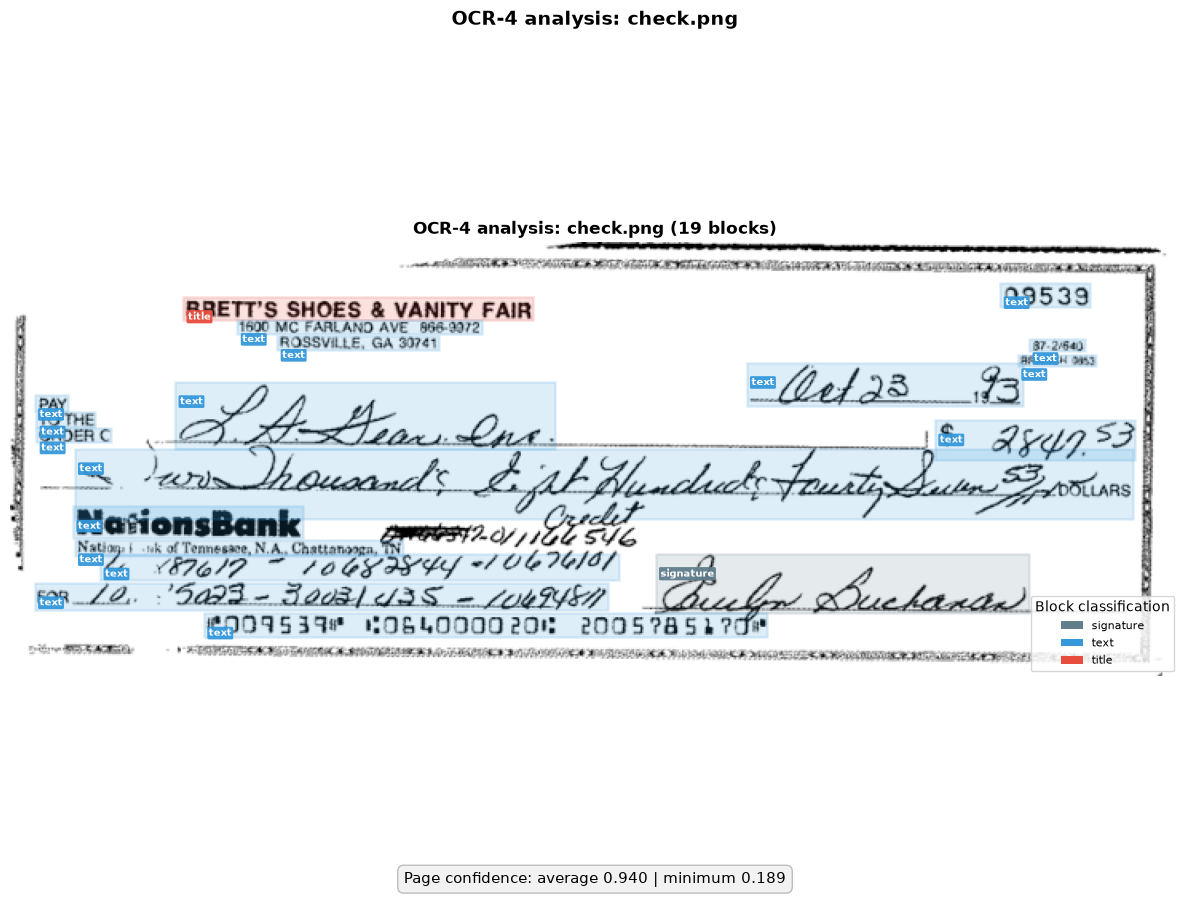

In [ ]:
page = ocr_response.get('pages', [{}])[0]
plot_bounding_boxes(
    IMAGE_PATH,
    page.get('blocks', []),
    title='OCR-4 analysis: check.png',
    confidence=page_confidence(page),
)


In [12]:
def annotation_json_schema(name: str, description: str, properties: dict) -> dict:
    return {
        'type': 'json_schema',
        'json_schema': {
            'name': name,
            'description': description,
            'schema': {
                'type': 'object',
                'properties': properties,
            },
        },
    }


CHECK_ANNOTATION_FORMAT = annotation_json_schema(
    'check_annotation',
    'Structured fields extracted from a check image.',
    {
        'check_number': {
            'type': 'string',
            'description': 'The check number, preserving leading zeros.',
        },
        'bank_name': {
            'type': 'string',
            'description': 'The bank name and address, ending at the state or postal code.',
        },
        'pay_to_the_order': {
            'type': 'string',
            'description': 'Only the name of the person or organization being paid.',
        },
        'signature': {
            'type': 'string',
            'description': (
                'Transcribe the handwritten name on the authorized signature line at the '
                'lower right of the check. Read the ink visually, even if OCR does not '
                'label it as text; return the full name when legible, otherwise null.'
            ),
        },
        'check_notes': {
            'type': 'string',
            'description': 'Remaining memo, routing, or check text.',
        },
        'check_amount': {
            'type': 'string',
            'description': 'The numeric check amount, including currency when visible.',
        },
        'check_date': {
            'type': 'string',
            'description': 'The check date exactly as printed, such as Oct 23 93.',
        },
        'amount_of_the_check': {
            'type': 'string',
            'description': 'The amount of the check; use the same value as check_amount.',
        },
    },
)


def annotate_check_document(image_path: Path) -> dict:
    encoded_image = encode_image(image_path)
    mime_type = mimetypes.guess_type(image_path.name)[0] or 'image/png'
    payload = {
        'model': MODEL_NAME,
        'document': {
            'type': 'document_url',
            'document_url': f'data:{mime_type};base64,{encoded_image}',
        },
        'include_image_base64': True,
        'document_annotation_format': CHECK_ANNOTATION_FORMAT,
        'document_annotation_prompt': (
            'Inspect the whole check image, including handwriting. Extract the printed and '
            'handwritten fields exactly. For signature, specifically inspect the handwritten '
            'authorized-signature line near the lower right and transcribe the signer name '
            'from the ink; do not require an OCR label. In this image the signature is a '
            'handwritten full name, not the payee. Preserve leading zeros in the check number, '
            'return only the payer name for pay_to_the_order, and use null only when a field '
            'is not visible or not legible. Do not invent values.'
        ),
    }
    response = requests.post(ENDPOINT, json=payload, headers=HEADERS, timeout=120)
    response.raise_for_status()
    response_json = response.json()
    annotation = response_json.get('document_annotation')
    if isinstance(annotation, str):
        annotation = json.loads(annotation)
    return annotation or {}


check_annotation = annotate_check_document(Path.cwd() / 'samples' / 'check.png')
display('Check document annotation:', check_annotation)


'Check document annotation:'

{'check_number': '09539',
 'bank_name': 'Nations Bank of Tennessee, N.A., Chattanooga, TN',
 'pay_to_the_order': 'L.A. Dean, Inc.',
 'signature': 'Evelyn Buchanan',
 'check_notes': 'FOR 10. 5023 - 30031435 - 1049481',
 'check_amount': '$ 2847.53',
 'check_date': 'Oct 23 93',
 'amount_of_the_check': '$ 2847.53'}

Handwritten Sample

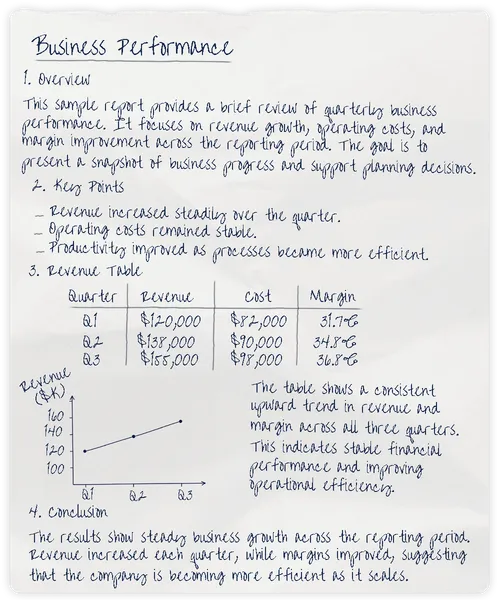

In [53]:
IMAGE_PATH = Path.cwd() / 'samples' / 'handwritten_sample.png'
display(Image(filename=str(IMAGE_PATH)))

In [54]:
ocr_response = call_ocr4(IMAGE_PATH)
text = extract_text(ocr_response)
display('OCR text:', text)


'OCR text:'

'# Business Performance ## 1. Overview This sample report provides a brief review of quarterly business performance. It focuses on revenue growth, operating costs, and margin improvement across the reporting period. The goal is to present a snapshot of business progress and support planning decisions. ## 2. Key Points - Revenue increased steadily over the quarter. - Operating costs remained stable. - Productivity improved as processes became more efficient. ## 3. Revenue Table | Quarter | Revenue | Cost | Margin | | --- | --- | --- | --- | | Q1 | $120,000 | $82,000 | 31.7% | | Q2 | $138,000 | $90,000 | 34.8% | | Q3 | $155,000 | $98,000 | 36.8% | Revenue ($K) ![img-0.jpeg](img-0.jpeg) The table shows a consistent upward trend in revenue and margin across all three quarters. This indicates stable financial performance and improving operational efficiency. ## 4. Conclusion The results show steady business growth across the reporting period. Revenue increased each quarter, while margins im

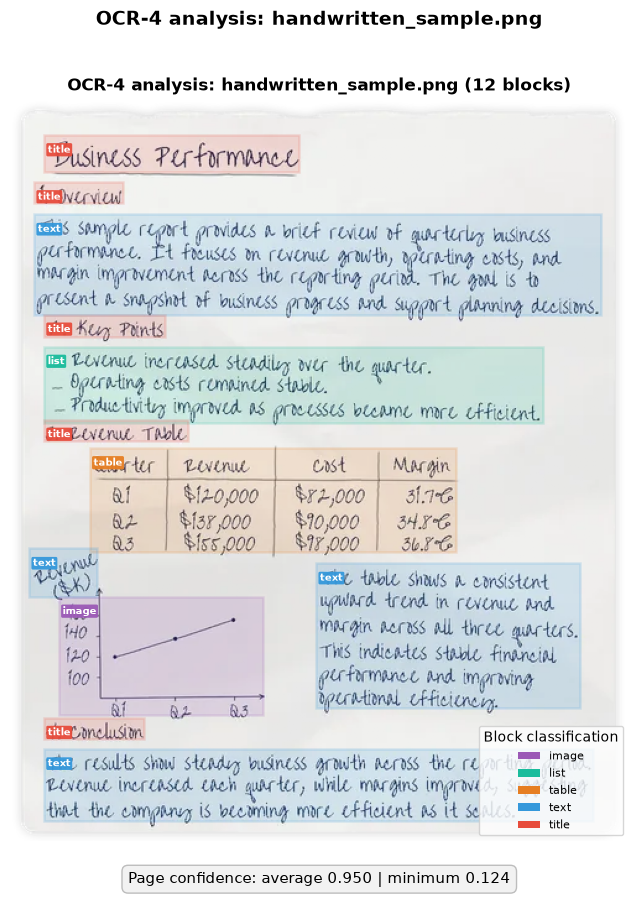

In [ ]:
page = ocr_response.get('pages', [{}])[0]
plot_bounding_boxes(
    IMAGE_PATH,
    page.get('blocks', []),
    title='OCR-4 analysis: handwritten_sample.png',
    confidence=page_confidence(page),
)


In [56]:
analysis = extract_handwritten_sample_analysis(ocr_response)
display('Tables, figure interpretation, and conclusion:', analysis)

'Tables, figure interpretation, and conclusion:'

{'text': '# Business Performance ## 1. Overview This sample report provides a brief review of quarterly business performance. It focuses on revenue growth, operating costs, and margin improvement across the reporting period. The goal is to present a snapshot of business progress and support planning decisions. ## 2. Key Points - Revenue increased steadily over the quarter. - Operating costs remained stable. - Productivity improved as processes became more efficient. ## 3. Revenue Table | Quarter | Revenue | Cost | Margin | | --- | --- | --- | --- | | Q1 | $120,000 | $82,000 | 31.7% | | Q2 | $138,000 | $90,000 | 34.8% | | Q3 | $155,000 | $98,000 | 36.8% | Revenue ($K) ![img-0.jpeg](img-0.jpeg) The table shows a consistent upward trend in revenue and margin across all three quarters. This indicates stable financial performance and improving operational efficiency. ## 4. Conclusion The results show steady business growth across the reporting period. Revenue increased each quarter, while m

'Handwritten sample annotations:'

{'document_annotation': {'tables': [{'title': 'Revenue Table',
    'headers': ['Quarter', 'Revenue', 'Cost', 'Margin'],
    'rows': [{'Quarter': 'Q1',
      'Revenue': '$120,000',
      'Cost': '$82,000',
      'Margin': '31.7%'},
     {'Quarter': 'Q2',
      'Revenue': '$138,000',
      'Cost': '$90,000',
      'Margin': '34.8%'},
     {'Quarter': 'Q3',
      'Revenue': '$155,000',
      'Cost': '$98,000',
      'Margin': '36.8%'}]}],
  'figure_interpretation': 'The figure shows a consistent upward trend in revenue across the three quarters, indicating steady financial growth.',
  'conclusion': 'The results show steady business growth across the reporting period. Revenue increased each quarter, while margins improved, suggesting that the company is becoming more efficient as it scales.'},
 'pages_with_bbox_annotations': [{'index': 0,
   'markdown': '# Business Performance\n\n## 1. Overview\n\nThis sample report provides a brief review of quarterly business performance. It focuses on r
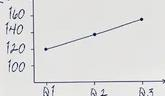

In [ ]:
# Azure Foundry document and BBOX annotations for the handwritten sample
HANDWRITTEN_DOCUMENT_ANNOTATION_FORMAT = annotation_json_schema(
    'handwritten_sample_annotation',
    'Structured analysis of tables, figures, and the conclusion in the handwritten sample.',
    {
        'tables': {
            'type': 'array',
            'description': 'All tables found in the document.',
            'items': {
                'type': 'object',
                'properties': {
                    'title': {'type': 'string', 'description': 'The table title or topic.'},
                    'headers': {
                        'type': 'array',
                        'items': {'type': 'string'},
                        'description': 'Column headers in reading order.',
                    },
                    'rows': {
                        'type': 'array',
                        'items': {'type': 'object'},
                        'description': 'Table rows keyed by the column headers.',
                    },
                },
            },
        },
        'figure_interpretation': {
            'type': 'string',
            'description': 'Explain the trend or meaning shown by each figure or chart.',
        },
        'conclusion': {
            'type': 'string',
            'description': 'The exact conclusion text and its main takeaway.',
        },
    },
)

HANDWRITTEN_BBOX_ANNOTATION_FORMAT = annotation_json_schema(
    'handwritten_figure_annotation',
    'Interpretation of an extracted figure or chart.',
    {
        'image_type': {
            'type': 'string',
            'description': 'The type of extracted image, chart, or figure.',
        },
        'short_description': {
            'type': 'string',
            'description': 'A concise description of the figure.',
        },
        'summary': {
            'type': 'string',
            'description': 'Interpret what the figure shows, including trends.',
        },
    },
)


def annotate_handwritten_sample(image_path: Path) -> dict:
    encoded_image = encode_image(image_path)
    mime_type = mimetypes.guess_type(image_path.name)[0] or 'image/png'
    payload = {
        'model': MODEL_NAME,
        'document': {
            'type': 'document_url',
            'document_url': f'data:{mime_type};base64,{encoded_image}',
        },
        'include_image_base64': True,
        'document_annotation_format': HANDWRITTEN_DOCUMENT_ANNOTATION_FORMAT,
        'bbox_annotation_format': HANDWRITTEN_BBOX_ANNOTATION_FORMAT,
        'document_annotation_prompt': (
            'Analyze the handwritten sample as a business report. Extract every table '
            'with its headers and rows, interpret the extracted figure or chart, and '
            'quote the conclusion accurately. Do not invent values.'
        ),
    }
    response = requests.post(ENDPOINT, json=payload, headers=HEADERS, timeout=120)
    response.raise_for_status()
    response_json = response.json()
    document_annotation = response_json.get('document_annotation')
    if isinstance(document_annotation, str):
        document_annotation = json.loads(document_annotation)
    for page in response_json.get('pages', []):
        for image in page.get('images', []):
            image_annotation = image.get('image_annotation')
            if isinstance(image_annotation, str):
                image['image_annotation'] = json.loads(image_annotation)
    return {
        'document_annotation': document_annotation or {},
        'pages_with_bbox_annotations': response_json.get('pages', []),
    }


handwritten_annotation = annotate_handwritten_sample(
    Path.cwd() / 'samples' / 'handwritten_sample.png'
)
display('Handwritten sample annotations:', handwritten_annotation)

Harder Handwritten Sample

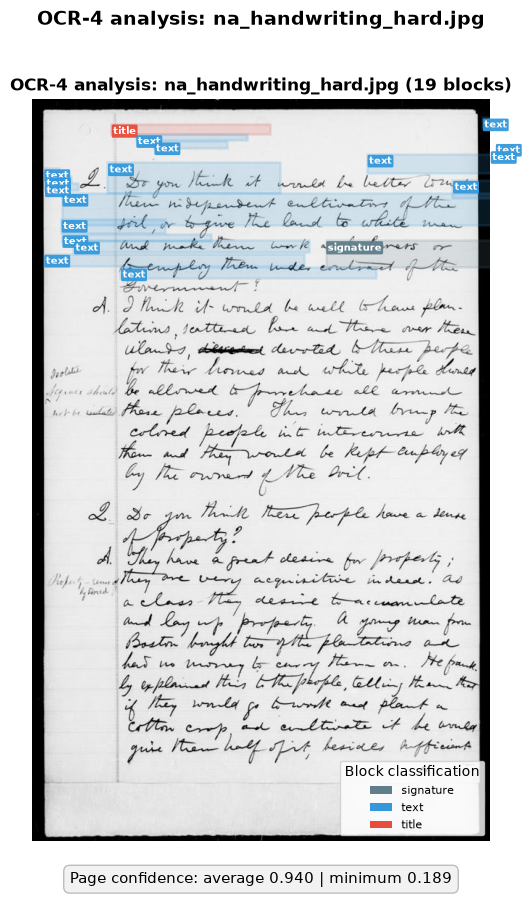

In [13]:

IMAGE_PATH = Path.cwd() / 'samples' / 'na_handwriting_hard.jpg'

page = ocr_response.get('pages', [{}])[0]
plot_bounding_boxes(
    IMAGE_PATH,
    page.get('blocks', []),
    title='OCR-4 analysis: na_handwriting_hard.jpg',
    confidence=page_confidence(page),
)

In [14]:
ocr_response = call_ocr4(IMAGE_PATH)
text = extract_text(ocr_response)
display('OCR text:', text)

'OCR text:'

'Isolated Figures should not be isolated Property - sense of byword. 2. Do you think it would be better to make them independent cultivators of the soil, or to give the land to white men and make them work as laborers or to employ them under contract of the Government? A. I think it would be well to have plan- ations, scattered here and there over these islands, devoted to these people for their homes and white people should be allowed to purchase all around these places. This would bring the colored people into intercourse with them and they would be kept employed by the owners of the soil. 2. Do you think these people have a sense of property? A. They have a great desire for property; they are very acquisitive indeed. As a class they desire to accumulate and lay up property. A young man from Boston bought two of the plantations and had no money to carry them on. He frank- ly explained this to the people, telling them that if they would go to work and plant a cotton crop and cultivate